In [4]:
import pandas as pd
import numpy as np
# import quantile_forest as qrf
import matplotlib.pyplot as plt
import pickle
from datetime import timedelta

import sys
sys.path.append('..')

from sklearn.preprocessing import MinMaxScaler
from src.data_preparation import feature_engineering, prepare_time_series

In [36]:
X_train = np.load('../X_train_final.npy')
y_train = np.load('../y_train_final.npy')

X_val = np.load('../X_val_final.npy')
y_val = np.load('../y_val_final.npy')

X_test = np.load('../X_test_final.npy')
y_test = np.load('../y_test_final.npy')

reshape_params_x = (-1, X_train.shape[1]*X_train.shape[2])
reshape_params_y = (-1, y_train.shape[1]*y_train.shape[2])

X_train = X_train.reshape(reshape_params_x)
X_val = X_val.reshape(reshape_params_x)
X_test = X_test.reshape(reshape_params_x)

y_train = y_train.reshape(reshape_params_y)
y_val = y_val.reshape(reshape_params_y)
y_test = y_test.reshape(reshape_params_y)

In [2]:
df_anom = pd.read_csv(
    '../data/anomaly_meteo.csv', 
    index_col=['Unnamed: 0'],
    parse_dates=['position_timestamp']
)
df_anom.info()

df_anom.drop(columns=['windWaveDirection', 'windWaveHeight'], inplace=True)

df_anom = df_anom.rename(columns={
    'course': 'COG',
    'heading': 'Heading',
    'position_timestamp': '# Timestamp',
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'speed': 'SOG'
})
df_anom['MMSI'] = 414270000

dfs = []
above_interpolation_limit = 0

df_anom['Heading'] = np.clip( df_anom['Heading'], 0, 360 )
df_anom['COG'] = np.clip( df_anom['COG'], 0, 360 )

df_anom['hour'] = df_anom['# Timestamp'].dt.round('h')
df_anom = df_anom.drop(columns=['hour'])

df_anom, timestamps = feature_engineering(df_anom, return_timestamps=True)
df_anom.drop(columns=['Latitude', 'Longitude'], inplace=True)

min_max_scale_cols = [
    # 'Latitude',
    # 'Longitude',
    'SOG',
    'currentSpeed',
    'gust',
    'swellHeight',
    'waveHeight',
    'windSpeed'
]

with open('../output/lstm-min-max-scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

df_anom[min_max_scale_cols] = scaler.fit_transform(
    df_anom[min_max_scale_cols].values
)

df_anom.dropna(inplace=True)
df_anom.drop(columns=['time'], inplace=True)

X_arr, y_arr = prepare_time_series(df_anom)

<class 'pandas.DataFrame'>
RangeIndex: 1439 entries, 0 to 1438
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   position_timestamp  1439 non-null   datetime64[us, UTC]
 1   latitude            1439 non-null   float64            
 2   longitude           1439 non-null   float64            
 3   speed               1439 non-null   float64            
 4   course              1439 non-null   float64            
 5   heading             1439 non-null   float64            
 6   currentDirection    1439 non-null   float64            
 7   currentSpeed        1439 non-null   float64            
 8   gust                1439 non-null   float64            
 9   swellDirection      1439 non-null   float64            
 10  swellHeight         1439 non-null   float64            
 11  time                1439 non-null   str                
 12  waveDirection       1439 non-null   float64  

In [3]:
X_arr.dump('../anom-x.npy')
y_arr.dump('../anom-y.npy')

In [8]:
params = {
    'max_depth': 32,
    'max_samples': 1.0,
    'max_samples_leaf': 1,
    'max_features': 0.75
}

In [39]:
qrf_model_cog = qrf.RandomForestQuantileRegressor(
    **params,
    n_jobs=-1,
    verbose=True
)

qrf_model_cog.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed: 24.8min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 66.5min finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.1s finished


: 

In [1]:
y_pred = qrf_model_cog.predict(X_arr.reshape(reshape_params), quantiles=[0.025, 0.975])
y_low = y_pred[:, 0]
y_high = y_pred[:, 1]

NameError: name 'qrf_model_cog' is not defined

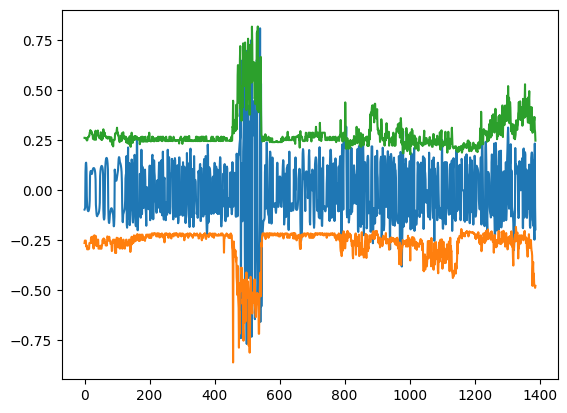

In [24]:
plt.plot(y_arr[:, 0, 0])
plt.plot(y_low)
plt.plot(y_high)

In [25]:
np.mean(
    (y_low[450:] < y_arr[450:, 0, 0]) &
    (y_high[450:] > y_arr[450:, 0, 0])
)

np.float64(0.9584221748400853)

In [27]:
y_pred_val = qrf_model_cog.predict(X_val, quantiles=[0.025, 0.975])
y_low_val = y_pred_val[:, 0]
y_high_val = y_pred_val[:, 1]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.4s finished


In [28]:
in_pi_mask = (
    (y_val[:, 0, 0] < y_high_val) &
    (y_val[:, 0, 0] > y_low_val)
)

In [29]:
val_mmsis = np.load('../val-mmsis-test.npy', allow_pickle=True)
val_days = np.load('../val-days-test.npy', allow_pickle=True)

In [31]:
group_results = {}
for ix, (mmsi, day) in enumerate(zip(val_mmsis, val_days)):
    
    if (mmsi, day) not in group_results:
        group_results[(mmsi, day)] = [ in_pi_mask[ix] ]
    else:
        group_results[(mmsi, day)].append( in_pi_mask[ix] )

In [33]:
df = []

for (mmsi, day), pi_masks in group_results.items():
    df.append({
        'mmsi': mmsi,
        'day': day,
        'delta_cog': np.mean(pi_masks),
    })

df = pd.DataFrame(df)
df

,mmsi,day,delta_cog
0,305919000,2024-12-01,1.000000
1,305922000,2024-12-06,0.994152
2,305922000,2024-12-07,0.993127
3,305943000,2024-11-15,1.000000
4,305967000,2024-11-15,0.942122
...,...,...,...
323,518999083,2024-11-18,0.992000
324,518999147,2024-12-12,0.994505
325,525007403,2024-12-06,0.872340
326,525007403,2024-12-07,0.958937


In [34]:
np.quantile( df['delta_cog'], 0.05 )

np.float64(0.8848529411764705)